# Population Growth Analysis and Forecasting

This notebook performs data cleaning, exploratory analysis, advanced analysis, visualization, and population forecasting using the UN World Population Prospects 2024 dataset.

## Project scope

- Historical period used for analysis: **1950–2023**
- Unit of population: **persons**
- Geographic level: **Country/Area**
- UN scenario used: **Medium**
- Forecasting method: **Linear Regression**
- Forecast horizon: **2024–2033**


## Part 2: Data Cleaning and Preprocessing

In [1]:
from pathlib import Path
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_PATH = Path(
    "/kaggle/input/datasets/adityapatil082001/"
    "world-population-by-sex/WPP2024_TotalPopulationBySex.csv"
)

OUTPUT_DIR = Path("/kaggle/working/population_analysis_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_DATA_PATH = OUTPUT_DIR / "population_cleaned_1950_2023.csv"

HISTORICAL_START_YEAR = 1950
HISTORICAL_END_YEAR = 2023
FORECAST_START_YEAR = 2024
FORECAST_END_YEAR = 2033

print("Input path:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)


Input path: /kaggle/input/datasets/adityapatil082001/world-population-by-sex/WPP2024_TotalPopulationBySex.csv
Output directory: /kaggle/working/population_analysis_outputs


In [2]:
# Load the original dataset
raw_df = pd.read_csv(DATA_PATH, low_memory=False)

print("Original dataset shape:", raw_df.shape)
print("Year range:", raw_df["Time"].min(), "to", raw_df["Time"].max())
print("Unique locations:", raw_df["Location"].nunique())
print("Exact duplicate rows:", raw_df.duplicated().sum())

display(raw_df.head())


Original dataset shape: (720210, 18)
Year range: 1950 to 2100
Unique locations: 553
Exact duplicate rows: 0


,SortOrder,LocID,Notes,ISO3_code,ISO2_code,SDMX_code,LocTypeID,LocTypeName,ParentID,Location,VarID,Variant,Time,MidPeriod,PopMale,PopFemale,PopTotal,PopDensity
0,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1950,"1,950.500","35,880.164","33,333.260","69,213.424",12.514
1,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1951,"1,951.500","36,615.257","34,067.503","70,682.760",12.780
2,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1952,"1,952.500","37,394.815","34,843.901","72,238.716",13.061
3,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1953,"1,953.500","38,216.385","35,659.980","73,876.364",13.357
4,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,2,Medium,1954,"1,954.500","39,082.204","36,518.249","75,600.454",13.669


In [3]:
# Review the original structure and key categories
dataset_overview = pd.DataFrame(
    {
        "Measure": [
            "Rows",
            "Columns",
            "Unique locations",
            "Minimum year",
            "Maximum year",
            "Missing PopTotal values",
            "Exact duplicate rows",
        ],
        "Value": [
            raw_df.shape[0],
            raw_df.shape[1],
            raw_df["Location"].nunique(),
            raw_df["Time"].min(),
            raw_df["Time"].max(),
            raw_df["PopTotal"].isna().sum(),
            raw_df.duplicated().sum(),
        ],
    }
)

display(dataset_overview)
display(raw_df["LocTypeName"].value_counts(dropna=False).to_frame("Rows"))
display(raw_df["Variant"].value_counts(dropna=False).to_frame("Rows").head(10))


,Measure,Value
0,Rows,720210
1,Columns,18
2,Unique locations,553
3,Minimum year,1950
4,Maximum year,2100
5,Missing PopTotal values,0
6,Exact duplicate rows,0


,Rows
LocTypeName,
Country/Area,346020
NaN,251550
Ad Hoc groups,33580
Subregion,30660
Income group,13140
SDG region,13140
Special other,10220
Development group,10220
Geographic region,10220


,Rows
Variant,
Medium,83805
High,42735
Low,42735
Constant fertility,42735
Instant replacement,42735
Zero migration,42735
Constant mortality,42735
No change,42735
Momentum,42735


In [4]:
# Build a location hierarchy lookup
location_lookup = (
    raw_df[["LocID", "Location", "LocTypeName", "ParentID"]]
    .assign(_has_type=raw_df["LocTypeName"].notna().astype(int))
    .sort_values(["LocID", "_has_type"], ascending=[True, False])
    .drop_duplicates("LocID")
    .drop(columns="_has_type")
)

# Retain country-level records under the Medium scenario
country_df = raw_df[
    (raw_df["LocTypeName"] == "Country/Area")
    & (raw_df["Variant"] == "Medium")
    & (
        raw_df["Time"].between(
            HISTORICAL_START_YEAR,
            HISTORICAL_END_YEAR,
        )
    )
].copy()

print("Country-level historical rows:", len(country_df))
print("Countries/areas:", country_df["Location"].nunique())
print("Selected year range:", country_df["Time"].min(), "to", country_df["Time"].max())


Country-level historical rows: 17538
Countries/areas: 237
Selected year range: 1950 to 2023


In [5]:
# Map the direct parent as subregion
subregion_lookup = location_lookup.rename(
    columns={
        "LocID": "Subregion_ID",
        "Location": "Subregion",
        "LocTypeName": "Subregion_Type",
        "ParentID": "Continent_ID",
    }
)

country_df = country_df.merge(
    subregion_lookup,
    left_on="ParentID",
    right_on="Subregion_ID",
    how="left",
)

# Map the parent of each subregion as continent
continent_lookup = location_lookup.rename(
    columns={
        "LocID": "Continent_ID_Lookup",
        "Location": "Continent",
        "LocTypeName": "Continent_Type",
        "ParentID": "World_ID",
    }
)

country_df = country_df.merge(
    continent_lookup,
    left_on="Continent_ID",
    right_on="Continent_ID_Lookup",
    how="left",
)

# Northern America uses a different parent identifier in this file
north_america_codes = ["BMU", "CAN", "GRL", "SPM", "USA"]
north_america_mask = country_df["ISO3_code"].isin(north_america_codes)
country_df.loc[north_america_mask, "Subregion"] = "Northern America"
country_df.loc[north_america_mask, "Continent"] = "Northern America"

display(
    country_df[
        ["Location", "ISO3_code", "Subregion", "Continent"]
    ]
    .drop_duplicates()
    .head(15)
)


,Location,ISO3_code,Subregion,Continent
0,Burundi,BDI,Eastern Africa,Africa
74,Comoros,COM,Eastern Africa,Africa
148,Djibouti,DJI,Eastern Africa,Africa
222,Eritrea,ERI,Eastern Africa,Africa
296,Ethiopia,ETH,Eastern Africa,Africa
370,Kenya,KEN,Eastern Africa,Africa
444,Madagascar,MDG,Eastern Africa,Africa
518,Malawi,MWI,Eastern Africa,Africa
592,Mauritius,MUS,Eastern Africa,Africa
666,Mayotte,MYT,Eastern Africa,Africa


In [6]:
# Select and rename the required fields
cleaned_df = country_df[
    [
        "LocID",
        "ISO3_code",
        "Location",
        "Subregion",
        "Continent",
        "Time",
        "PopTotal",
        "PopMale",
        "PopFemale",
        "PopDensity",
    ]
].copy()

cleaned_df = cleaned_df.rename(
    columns={
        "LocID": "Country_ID",
        "ISO3_code": "Country_Code",
        "Location": "Country",
        "Time": "Year",
        "PopTotal": "Population_Thousands",
        "PopMale": "Male_Population_Thousands",
        "PopFemale": "Female_Population_Thousands",
        "PopDensity": "Population_Density",
    }
)

numeric_columns = [
    "Year",
    "Population_Thousands",
    "Male_Population_Thousands",
    "Female_Population_Thousands",
    "Population_Density",
]

for column in numeric_columns:
    cleaned_df[column] = pd.to_numeric(
        cleaned_df[column],
        errors="coerce",
    )

cleaned_df["Country"] = cleaned_df["Country"].astype(str).str.strip()
cleaned_df["Country_Code"] = (
    cleaned_df["Country_Code"].astype(str).str.strip().str.upper()
)
cleaned_df["Subregion"] = (
    cleaned_df["Subregion"].fillna("Unknown").astype(str).str.strip()
)
cleaned_df["Continent"] = (
    cleaned_df["Continent"].fillna("Unknown").astype(str).str.strip()
)


In [7]:
# Handle missing values and duplicate country-year records
missing_before = cleaned_df.isna().sum()

cleaned_df = cleaned_df.dropna(
    subset=[
        "Country",
        "Country_Code",
        "Year",
        "Population_Thousands",
    ]
)

duplicates_before = cleaned_df.duplicated(
    subset=["Country_Code", "Year"]
).sum()

cleaned_df = cleaned_df.drop_duplicates(
    subset=["Country_Code", "Year"],
    keep="first",
)

cleaned_df["Year"] = cleaned_df["Year"].astype(int)

# Convert population values from thousands to persons
cleaned_df["Population"] = (
    cleaned_df["Population_Thousands"] * 1000
).round().astype("int64")

cleaned_df["Male_Population"] = (
    cleaned_df["Male_Population_Thousands"] * 1000
).round().astype("int64")

cleaned_df["Female_Population"] = (
    cleaned_df["Female_Population_Thousands"] * 1000
).round().astype("int64")

cleaned_df = cleaned_df.sort_values(
    ["Country_Code", "Year"]
).reset_index(drop=True)

print("Duplicate country-year records before removal:", duplicates_before)
print("Duplicate country-year records after removal:",
      cleaned_df.duplicated(["Country_Code", "Year"]).sum())


Duplicate country-year records before removal: 0
Duplicate country-year records after removal: 0


In [8]:
# Create calculated variables
cleaned_df["Annual_Population_Change"] = (
    cleaned_df.groupby("Country_Code")["Population"].diff()
)

cleaned_df["Percentage_Growth_Rate"] = (
    cleaned_df.groupby("Country_Code")["Population"]
    .pct_change(fill_method=None)
    .mul(100)
)

cleaned_df["Decade"] = (
    cleaned_df["Year"] // 10
) * 10

def classify_growth(rate):
    if pd.isna(rate):
        return "Not Available"
    if rate < 0:
        return "Negative"
    if rate < 1:
        return "Low"
    if rate < 2:
        return "Medium"
    return "High"

cleaned_df["Growth_Category"] = (
    cleaned_df["Percentage_Growth_Rate"].apply(classify_growth)
)

cleaned_df = cleaned_df[
    [
        "Country_ID",
        "Country_Code",
        "Country",
        "Subregion",
        "Continent",
        "Year",
        "Population",
        "Male_Population",
        "Female_Population",
        "Population_Density",
        "Annual_Population_Change",
        "Percentage_Growth_Rate",
        "Decade",
        "Growth_Category",
    ]
]

cleaned_df.to_csv(CLEANED_DATA_PATH, index=False)

print("Cleaned dataset saved to:", CLEANED_DATA_PATH)
display(cleaned_df.head())


Cleaned dataset saved to: /kaggle/working/population_analysis_outputs/population_cleaned_1950_2023.csv


,Country_ID,Country_Code,Country,Subregion,Continent,Year,Population,Male_Population,Female_Population,Population_Density,Annual_Population_Change,Percentage_Growth_Rate,Decade,Growth_Category
0,533,ABW,Aruba,Caribbean,Latin America and the Caribbean,1950,42738,20916,21823,237.433,NaN,NaN,1950,Not Available
1,533,ABW,Aruba,Caribbean,Latin America and the Caribbean,1951,43858,21476,22383,243.656,"1,120.000",2.621,1950,High
2,533,ABW,Aruba,Caribbean,Latin America and the Caribbean,1952,45029,22064,22965,250.161,"1,171.000",2.670,1950,High
3,533,ABW,Aruba,Caribbean,Latin America and the Caribbean,1953,46245,22674,23572,256.919,"1,216.000",2.700,1950,High
4,533,ABW,Aruba,Caribbean,Latin America and the Caribbean,1954,47494,23296,24198,263.856,"1,249.000",2.701,1950,High


In [9]:
# Validate the cleaned dataset
data_quality_summary = pd.DataFrame(
    {
        "Check": [
            "Final rows",
            "Final columns",
            "Countries/areas",
            "Minimum year",
            "Maximum year",
            "Missing country values",
            "Missing year values",
            "Missing population values",
            "Duplicate country-year records",
            "Non-positive population values",
        ],
        "Result": [
            cleaned_df.shape[0],
            cleaned_df.shape[1],
            cleaned_df["Country_Code"].nunique(),
            cleaned_df["Year"].min(),
            cleaned_df["Year"].max(),
            cleaned_df["Country"].isna().sum(),
            cleaned_df["Year"].isna().sum(),
            cleaned_df["Population"].isna().sum(),
            cleaned_df.duplicated(["Country_Code", "Year"]).sum(),
            (cleaned_df["Population"] <= 0).sum(),
        ],
    }
)

data_quality_summary.to_csv(
    TABLE_DIR / "data_quality_summary.csv",
    index=False,
)

display(data_quality_summary)


,Check,Result
0,Final rows,17538
1,Final columns,14
2,Countries/areas,237
3,Minimum year,1950
4,Maximum year,2023
5,Missing country values,0
6,Missing year values,0
7,Missing population values,0
8,Duplicate country-year records,0
9,Non-positive population values,0


## Part 3: Exploratory Data Analysis

In [10]:
# Basic population summaries
latest_year = cleaned_df["Year"].max()
latest_df = cleaned_df[
    cleaned_df["Year"] == latest_year
].copy()

total_population_by_year = (
    cleaned_df.groupby("Year", as_index=False)["Population"].sum()
)

average_population_by_country = (
    cleaned_df.groupby(
        ["Country_Code", "Country", "Continent"],
        as_index=False,
    )["Population"]
    .mean()
    .sort_values("Population", ascending=False)
    .rename(columns={"Population": "Average_Population"})
)

maximum_population_record = cleaned_df.loc[
    cleaned_df["Population"].idxmax()
]

minimum_population_record = cleaned_df.loc[
    cleaned_df["Population"].idxmin()
]

top_10_latest = latest_df.nlargest(
    10,
    "Population",
)[["Country", "Continent", "Population"]]

bottom_10_latest = latest_df.nsmallest(
    10,
    "Population",
)[["Country", "Continent", "Population"]]

total_population_by_year.to_csv(
    TABLE_DIR / "total_population_by_year.csv",
    index=False,
)
average_population_by_country.to_csv(
    TABLE_DIR / "average_population_by_country.csv",
    index=False,
)
top_10_latest.to_csv(
    TABLE_DIR / "top_10_countries_latest_year.csv",
    index=False,
)
bottom_10_latest.to_csv(
    TABLE_DIR / "bottom_10_countries_latest_year.csv",
    index=False,
)

print("Latest year:", latest_year)
print("\nMaximum population observation:")
display(maximum_population_record.to_frame("Value"))

print("\nMinimum population observation:")
display(minimum_population_record.to_frame("Value"))

print("\nTop 10 most populated countries:")
display(top_10_latest)

print("\nBottom 10 least populated countries/areas:")
display(bottom_10_latest)


Latest year: 2023

Maximum population observation:


,Value
Country_ID,356
Country_Code,IND
Country,India
Subregion,Southern Asia
Continent,Asia
Year,2023
Population,1438069596
Male_Population,741883264
Female_Population,696186332
Population_Density,483.679



Minimum population observation:


,Value
Country_ID,336
Country_Code,VAT
Country,Holy See
Subregion,Southern Europe
Continent,Europe
Year,2023
Population,496
Male_Population,237
Female_Population,259
Population_Density,"1,126.136"



Top 10 most populated countries:


,Country,Continent,Population
7251,India,Asia,1438069596
2885,China,Asia,1422584933
16427,United States of America,Northern America,343477335
7103,Indonesia,Asia,281190067
12135,Pakistan,Asia,247504495
11469,Nigeria,Africa,227882945
2219,Brazil,Latin America and the Caribbean,211140729
1479,Bangladesh,Asia,171466990
13319,Russian Federation,Europe,145440500
9989,Mexico,Latin America and the Caribbean,129739759



Bottom 10 least populated countries/areas:


,Country,Continent,Population
16575,Holy See,Europe,496
11617,Niue,Oceania,1817
15465,Tokelau,Oceania,2397
5105,Falkland Islands (Malvinas),Latin America and the Caribbean,3477
10803,Montserrat,Latin America and the Caribbean,4420
13763,Saint Helena,Africa,5289
14207,Saint Pierre and Miquelon,Northern America,5681
15983,Tuvalu,Oceania,9816
1849,Saint Barthélemy,Latin America and the Caribbean,11085
17093,Wallis and Futuna Islands,Oceania,11370


In [11]:
# Growth analysis
valid_growth_df = cleaned_df.dropna(
    subset=["Percentage_Growth_Rate"]
).copy()

average_growth_by_country = (
    valid_growth_df.groupby(
        ["Country_Code", "Country", "Continent"],
        as_index=False,
    )
    .agg(
        Average_Annual_Growth_Rate=(
            "Percentage_Growth_Rate",
            "mean",
        ),
        Average_Annual_Change=(
            "Annual_Population_Change",
            "mean",
        ),
    )
    .sort_values(
        "Average_Annual_Growth_Rate",
        ascending=False,
    )
)

average_growth_by_continent = (
    valid_growth_df.groupby(
        ["Continent", "Year"],
        as_index=False,
    )
    .agg(
        Total_Population=("Population", "sum"),
        Total_Annual_Change=(
            "Annual_Population_Change",
            "sum",
        ),
    )
    .sort_values(["Continent", "Year"])
)

average_growth_by_continent["Continent_Growth_Rate"] = (
    average_growth_by_continent.groupby(
        "Continent"
    )["Total_Population"]
    .pct_change(fill_method=None)
    .mul(100)
)

continent_growth_summary = (
    average_growth_by_continent.groupby(
        "Continent",
        as_index=False,
    )["Continent_Growth_Rate"]
    .mean()
    .sort_values(
        "Continent_Growth_Rate",
        ascending=False,
    )
)

latest_negative_growth = latest_df[
    latest_df["Percentage_Growth_Rate"] < 0
][
    [
        "Country",
        "Continent",
        "Population",
        "Percentage_Growth_Rate",
    ]
].sort_values("Percentage_Growth_Rate")

average_growth_by_country.to_csv(
    TABLE_DIR / "average_growth_by_country.csv",
    index=False,
)
continent_growth_summary.to_csv(
    TABLE_DIR / "average_growth_by_continent.csv",
    index=False,
)
latest_negative_growth.to_csv(
    TABLE_DIR / "negative_growth_countries_latest_year.csv",
    index=False,
)

print("Countries/areas with negative growth in", latest_year)
display(latest_negative_growth.head(20))

print("\nHighest average growth rates:")
display(average_growth_by_country.head(10))

print("\nLowest average growth rates:")
display(average_growth_by_country.tail(10))

print("\nAverage growth by continent:")
display(continent_growth_summary)


Countries/areas with negative growth in 2023


,Country,Continent,Population,Percentage_Growth_Rate
16279,Ukraine,Europe,37732836,-8.078
9545,Saint Martin (French part),Latin America and the Caribbean,27515,-4.693
3255,Cook Islands,Oceania,14222,-3.403
10063,Marshall Islands,Oceania,38827,-3.119
5919,Guadeloupe,Latin America and the Caribbean,376517,-2.126
10581,Northern Mariana Islands,Oceania,45143,-2.029
16575,Holy See,Europe,496,-1.976
15983,Tuvalu,Oceania,9816,-1.761
739,American Samoa,Oceania,47521,-1.698
6215,Greece,Europe,10242908,-1.629



Highest average growth rates:


,Country_Code,Country,Continent,Average_Annual_Growth_Rate,Average_Annual_Change
6,ARE,United Arab Emirates,Asia,7.106,"144,761.219"
176,QAT,Qatar,Asia,6.899,"40,476.699"
62,ESH,Western Sahara,Africa,5.445,"7,763.959"
115,KWT,Kuwait,Asia,5.010,"64,175.671"
200,SXM,Sint Maarten (Dutch part),Latin America and the Caribbean,4.803,565.740
106,JOR,Jordan,Asia,4.589,"150,690.562"
181,SAU,Saudi Arabia,Asia,4.164,"432,342.753"
54,DJI,Djibouti,Africa,4.112,"14,939.904"
150,MYT,Mayotte,Africa,3.826,"4,047.795"
5,AND,Andorra,Europe,3.696,"1,025.479"



Lowest average growth rates:


,Country_Code,Country,Continent,Average_Annual_Growth_Rate,Average_Annual_Change
219,UKR,Ukraine,Europe,0.027,"5,780.123"
185,SHN,Saint Helena,Africa,0.021,0.890
92,HRV,Croatia,Europe,0.014,425.110
113,KNA,Saint Kitts and Nevis,Latin America and the Caribbean,-0.007,-6.493
126,LVA,Latvia,Europe,-0.021,-497.589
43,COK,Cook Islands,Oceania,-0.025,-6.452
20,BGR,Bulgaria,Europe,-0.086,"-6,201.479"
223,VAT,Holy See,Europe,-0.775,-5.260
156,NIU,Niue,Oceania,-1.214,-36.712
145,MSR,Montserrat,Latin America and the Caribbean,-1.421,-116.767



Average growth by continent:


,Continent,Continent_Growth_Rate
0,Africa,2.605
3,Latin America and the Caribbean,1.884
5,Oceania,1.767
1,Asia,1.726
4,Northern America,1.129
2,Europe,0.414


In [12]:
# Comparative analysis for five selected countries
comparison_countries = [
    "India",
    "China",
    "United States of America",
    "Nigeria",
    "Pakistan",
]

selected_country_trends = cleaned_df[
    cleaned_df["Country"].isin(comparison_countries)
][
    [
        "Country",
        "Year",
        "Population",
        "Annual_Population_Change",
        "Percentage_Growth_Rate",
    ]
].copy()

selected_country_summary = (
    selected_country_trends.groupby("Country", as_index=False)
    .agg(
        Start_Year=("Year", "min"),
        End_Year=("Year", "max"),
        Start_Population=("Population", "first"),
        End_Population=("Population", "last"),
        Average_Growth_Rate=(
            "Percentage_Growth_Rate",
            "mean",
        ),
    )
)

selected_country_summary["Absolute_Growth"] = (
    selected_country_summary["End_Population"]
    - selected_country_summary["Start_Population"]
)

selected_country_summary["Long_Term_Growth_Percent"] = (
    selected_country_summary["Absolute_Growth"]
    / selected_country_summary["Start_Population"]
    * 100
)

selected_country_summary.to_csv(
    TABLE_DIR / "selected_country_comparison.csv",
    index=False,
)

display(selected_country_summary)


,Country,Start_Year,End_Year,Start_Population,End_Population,Average_Growth_Rate,Absolute_Growth,Long_Term_Growth_Percent
0,China,1950,2023,544044358,1422584933,1.329,878540575,161.483
1,India,1950,2023,346278821,1438069596,1.971,1091790775,315.292
2,Nigeria,1950,2023,37283010,227882945,2.512,190599935,511.225
3,Pakistan,1950,2023,35849260,247504495,2.684,211655235,590.403
4,United States of America,1950,2023,154202680,343477335,1.104,189274655,122.744


## Part 4: Advanced Analysis


In [13]:
# Detect annual growth-rate outliers
growth_values = valid_growth_df["Percentage_Growth_Rate"]

q1 = growth_values.quantile(0.25)
q3 = growth_values.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

growth_outliers = valid_growth_df[
    (valid_growth_df["Percentage_Growth_Rate"] < lower_limit)
    | (valid_growth_df["Percentage_Growth_Rate"] > upper_limit)
][
    [
        "Country",
        "Continent",
        "Year",
        "Population",
        "Annual_Population_Change",
        "Percentage_Growth_Rate",
    ]
].sort_values(
    "Percentage_Growth_Rate",
    key=lambda series: series.abs(),
    ascending=False,
)

growth_outliers.to_csv(
    TABLE_DIR / "population_growth_outliers.csv",
    index=False,
)

print("IQR lower limit:", round(lower_limit, 3))
print("IQR upper limit:", round(upper_limit, 3))
print("Number of outlier observations:", len(growth_outliers))
display(growth_outliers.head(20))


IQR lower limit: -2.33
IQR upper limit: 5.719
Number of outlier observations: 567


,Country,Continent,Year,Population,Annual_Population_Change,Percentage_Growth_Rate
13081,Qatar,Asia,2007,1208595,"235,764.000",24.235
8550,Kuwait,Asia,1990,1684819,"-532,649.000",-24.021
9412,"China, Macao SAR",Asia,1964,225655,"43,520.000",23.894
6675,"China, Hong Kong SAR",Asia,1965,3855421,"719,393.000",22.940
8552,Kuwait,Asia,1992,1634961,"283,562.000",20.983
9505,Saint Martin (French part),Latin America and the Caribbean,1983,11485,"1,991.000",20.971
463,United Arab Emirates,Asia,1969,239660,"40,244.000",20.181
4615,Western Sahara,Africa,1977,77388,"12,899.000",20.002
8551,Kuwait,Asia,1991,1351399,"-333,420.000",-19.790
9506,Saint Martin (French part),Latin America and the Caribbean,1984,13733,"2,248.000",19.573


In [14]:
# Rank countries by long-term population growth
first_population = (
    cleaned_df.sort_values("Year")
    .groupby(
        ["Country_Code", "Country", "Continent"],
        as_index=False,
    )
    .first()[
        [
            "Country_Code",
            "Country",
            "Continent",
            "Year",
            "Population",
        ]
    ]
    .rename(
        columns={
            "Year": "Start_Year",
            "Population": "Start_Population",
        }
    )
)

last_population = (
    cleaned_df.sort_values("Year")
    .groupby(
        ["Country_Code", "Country", "Continent"],
        as_index=False,
    )
    .last()[
        [
            "Country_Code",
            "Country",
            "Continent",
            "Year",
            "Population",
        ]
    ]
    .rename(
        columns={
            "Year": "End_Year",
            "Population": "End_Population",
        }
    )
)

long_term_growth = first_population.merge(
    last_population,
    on=["Country_Code", "Country", "Continent"],
    how="inner",
)

long_term_growth["Absolute_Growth"] = (
    long_term_growth["End_Population"]
    - long_term_growth["Start_Population"]
)

long_term_growth["Percentage_Growth"] = (
    long_term_growth["Absolute_Growth"]
    / long_term_growth["Start_Population"]
    * 100
)

long_term_growth["Absolute_Growth_Rank"] = (
    long_term_growth["Absolute_Growth"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

long_term_growth["Percentage_Growth_Rank"] = (
    long_term_growth["Percentage_Growth"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

long_term_growth.to_csv(
    TABLE_DIR / "long_term_population_growth_ranking.csv",
    index=False,
)

print("Top countries by absolute population growth:")
display(
    long_term_growth.sort_values(
        "Absolute_Growth",
        ascending=False,
    ).head(10)
)

print("Top countries by percentage population growth:")
display(
    long_term_growth.sort_values(
        "Percentage_Growth",
        ascending=False,
    ).head(10)
)


Top countries by absolute population growth:


,Country_Code,Country,Continent,Start_Year,Start_Population,End_Year,End_Population,Absolute_Growth,Percentage_Growth,Absolute_Growth_Rank,Percentage_Growth_Rank
97,IND,India,Asia,1950,346278821,2023,1438069596,1091790775,315.292,1,106
38,CHN,China,Asia,1950,544044358,2023,1422584933,878540575,161.483,2,152
95,IDN,Indonesia,Asia,1950,68799025,2023,281190067,212391042,308.712,3,108
163,PAK,Pakistan,Asia,1950,35849260,2023,247504495,211655235,590.403,4,42
154,NGA,Nigeria,Africa,1950,37283010,2023,227882945,190599935,511.225,5,55
221,USA,United States of America,Northern America,1950,154202680,2023,343477335,189274655,122.744,6,164
29,BRA,Brazil,Latin America and the Caribbean,1950,53408551,2023,211140729,157732178,295.331,7,115
19,BGD,Bangladesh,Asia,1950,41206856,2023,171466990,130260134,316.113,8,105
65,ETH,Ethiopia,Africa,1950,17670412,2023,128691692,111021280,628.289,9,37
134,MEX,Mexico,Latin America and the Caribbean,1950,27587939,2023,129739759,102151820,370.277,10,89


Top countries by percentage population growth:


,Country_Code,Country,Continent,Start_Year,Start_Population,End_Year,End_Population,Absolute_Growth,Percentage_Growth,Absolute_Growth_Rank,Percentage_Growth_Rank
6,ARE,United Arab Emirates,Asia,1950,74512,2023,10642081,10567569,"14,182.372",77,1
176,QAT,Qatar,Asia,1950,24283,2023,2979082,2954799,"12,168.179",115,2
62,ESH,Western Sahara,Africa,1950,12960,2023,579729,566769,"4,373.218",157,3
115,KWT,Kuwait,Asia,1950,153958,2023,4838782,4684824,"3,042.923",101,4
200,SXM,Sint Maarten (Dutch part),Latin America and the Caribbean,1950,1450,2023,42749,41299,"2,848.207",200,5
106,JOR,Jordan,Asia,1950,438802,2023,11439213,11000411,"2,506.919",76,6
181,SAU,Saudi Arabia,Asia,1950,1703271,2023,33264292,31561021,"1,852.965",33,7
54,DJI,Djibouti,Africa,1950,62331,2023,1152944,1090613,"1,749.712",141,8
150,MYT,Mayotte,Africa,1950,20526,2023,316015,295489,"1,439.584",173,9
5,AND,Andorra,Europe,1950,5996,2023,80856,74860,"1,248.499",192,10


In [15]:
# Relationship between current population size and growth rate
latest_relationship = latest_df[
    [
        "Country",
        "Continent",
        "Population",
        "Population_Density",
        "Annual_Population_Change",
        "Percentage_Growth_Rate",
    ]
].dropna()

size_growth_correlation = latest_relationship[
    [
        "Population",
        "Population_Density",
        "Annual_Population_Change",
        "Percentage_Growth_Rate",
    ]
].corr()

print(
    "Correlation between population size and growth rate:",
    round(
        latest_relationship["Population"].corr(
            latest_relationship["Percentage_Growth_Rate"]
        ),
        4,
    ),
)

display(size_growth_correlation)


Correlation between population size and growth rate: -0.0228


,Population,Population_Density,Annual_Population_Change,Percentage_Growth_Rate
Population,1.000,-0.025,0.537,-0.023
Population_Density,-0.025,1.000,-0.028,-0.024
Annual_Population_Change,0.537,-0.028,1.000,0.264
Percentage_Growth_Rate,-0.023,-0.024,0.264,1.000


## Part 5: Data Visualization

Each visualization includes a clear title, axis labels, legend where required, and a short interpretation.


In [16]:
def save_current_figure(filename):
    output_path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )
    print("Saved:", output_path)

def millions(values):
    return values / 1_000_000

def billions(values):
    return values / 1_000_000_000


Saved: /kaggle/working/population_analysis_outputs/figures/01_total_population_over_time.png


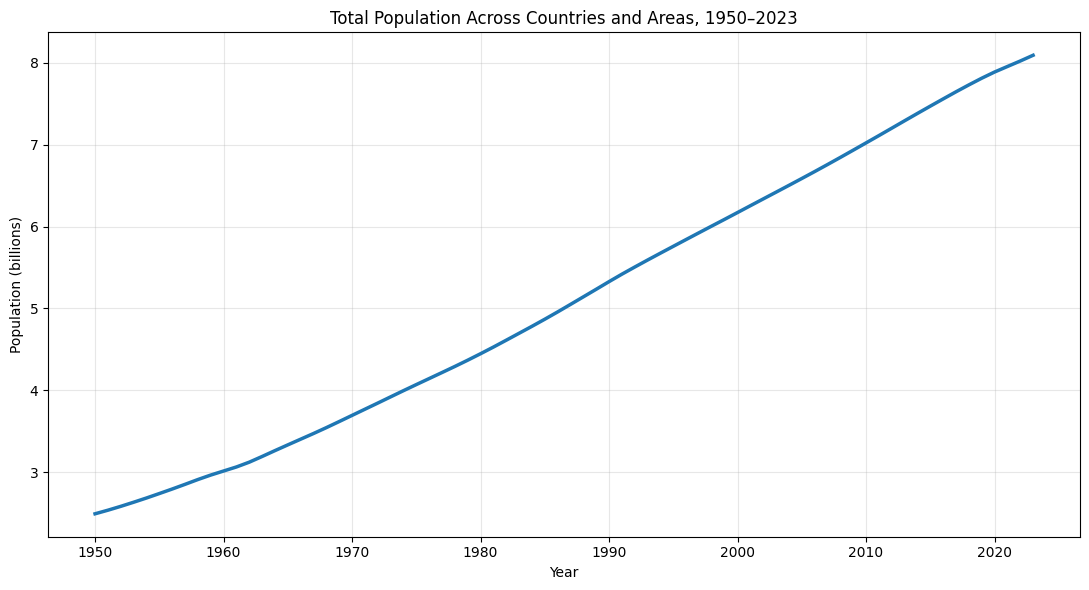

Interpretation: The combined population increased by 224.6% between 1950 and 2023.


In [17]:
# Visualization 1: Line chart for population growth over time 
plt.figure(figsize=(11, 6))
plt.plot(
    total_population_by_year["Year"],
    billions(total_population_by_year["Population"]),
    linewidth=2.5,
)
plt.title("Total Population Across Countries and Areas, 1950–2023")
plt.xlabel("Year")
plt.ylabel("Population (billions)")
plt.grid(alpha=0.3)

save_current_figure("01_total_population_over_time.png")
plt.show()

start_total = total_population_by_year.iloc[0]["Population"]
end_total = total_population_by_year.iloc[-1]["Population"]
increase_percent = (end_total - start_total) / start_total * 100

print(
    f"Interpretation: The combined population increased by "
    f"{increase_percent:,.1f}% between "
    f"{HISTORICAL_START_YEAR} and {HISTORICAL_END_YEAR}."
)


Saved: /kaggle/working/population_analysis_outputs/figures/03_top_10_most_populated_countries.png


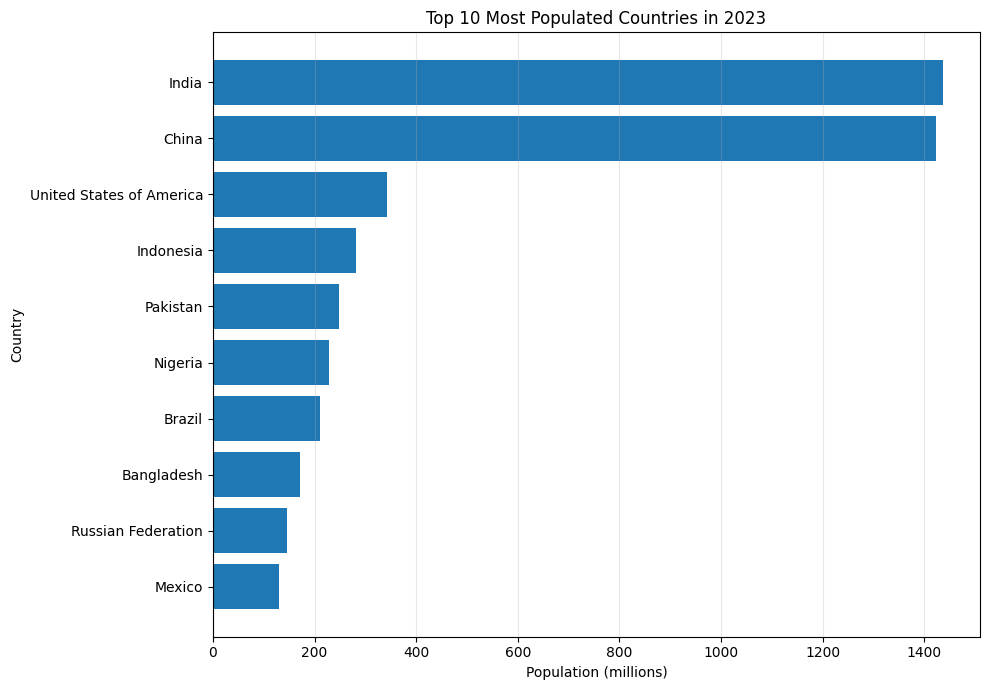

Interpretation: India and China dominate the ranking, while the remaining countries form a substantially lower tier.


In [18]:
# Visualization 2: Bar chart comparing top countries 
top_10_plot = top_10_latest.sort_values(
    "Population",
    ascending=True,
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_10_plot["Country"],
    millions(top_10_plot["Population"]),
)
plt.title(f"Top 10 Most Populated Countries in {latest_year}")
plt.xlabel("Population (millions)")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)

save_current_figure("03_top_10_most_populated_countries.png")
plt.show()

print(
    "Interpretation: India and China dominate the ranking, "
    "while the remaining countries form a substantially lower tier."
)


Saved: /kaggle/working/population_analysis_outputs/figures/04_population_distribution_by_continent.png


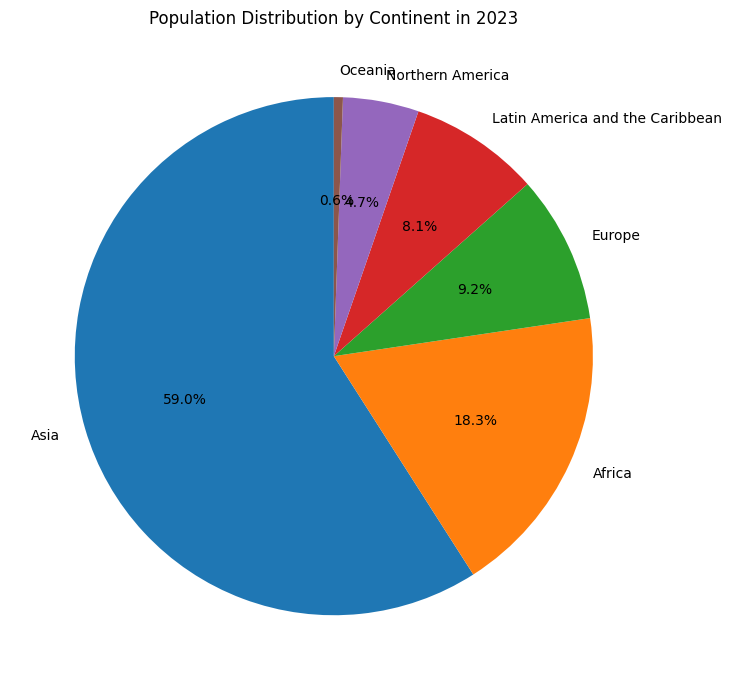

Interpretation: Asia has the largest share of the combined population in 2023.


In [19]:
# Visualization 3: Pie chart showing population distribution by continent
continent_distribution = (
    latest_df.groupby("Continent", as_index=False)["Population"]
    .sum()
    .sort_values("Population", ascending=False)
)

plt.figure(figsize=(9, 7))
plt.pie(
    continent_distribution["Population"],
    labels=continent_distribution["Continent"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title(f"Population Distribution by Continent in {latest_year}")

save_current_figure("04_population_distribution_by_continent.png")
plt.show()

largest_continent = continent_distribution.iloc[0]
print(
    f"Interpretation: {largest_continent['Continent']} has the "
    f"largest share of the combined population in {latest_year}."
)


Saved: /kaggle/working/population_analysis_outputs/figures/05_population_size_vs_growth_rate.png


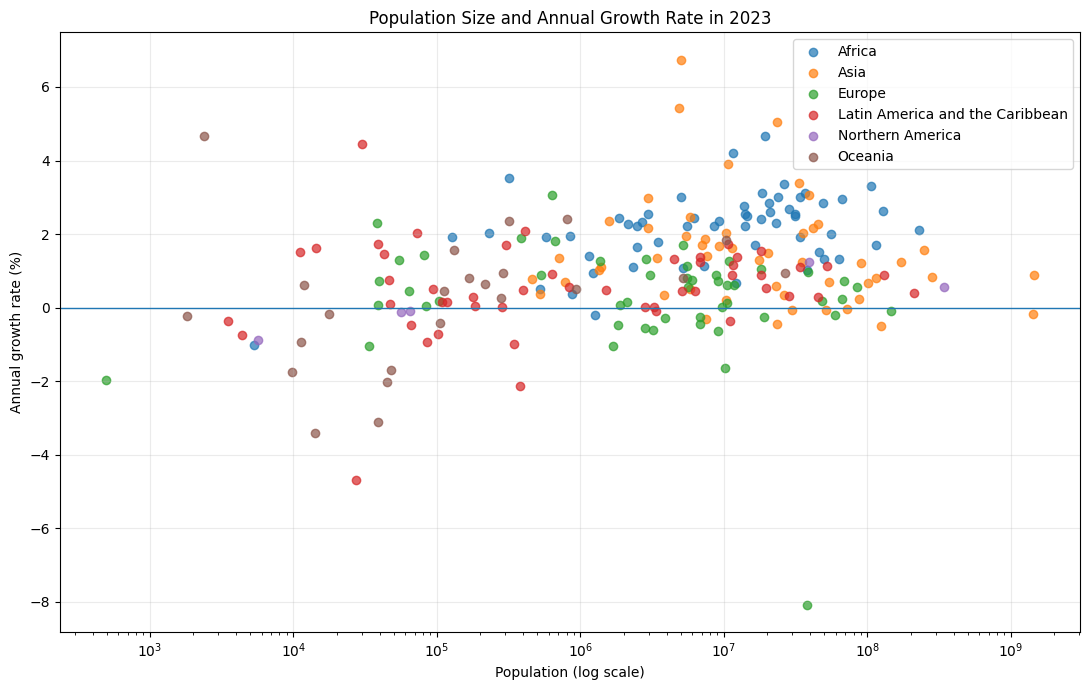

Interpretation: Population size alone does not determine whether a country is growing quickly or experiencing decline.


In [20]:
# Visualization 4: Scatter plot for trend analysis (Population size versus growth rate)
scatter_df = latest_relationship[
    latest_relationship["Population"] > 0
].copy()

plt.figure(figsize=(11, 7))

for continent in sorted(scatter_df["Continent"].unique()):
    continent_data = scatter_df[
        scatter_df["Continent"] == continent
    ]
    plt.scatter(
        continent_data["Population"],
        continent_data["Percentage_Growth_Rate"],
        alpha=0.7,
        label=continent,
    )

plt.xscale("log")
plt.axhline(0, linewidth=1)
plt.title(
    f"Population Size and Annual Growth Rate in {latest_year}"
)
plt.xlabel("Population (log scale)")
plt.ylabel("Annual growth rate (%)")
plt.legend()
plt.grid(alpha=0.25)

save_current_figure("05_population_size_vs_growth_rate.png")
plt.show()

print(
    "Interpretation: Population size alone does not determine "
    "whether a country is growing quickly or experiencing decline."
)


Saved: /kaggle/working/population_analysis_outputs/figures/06_population_correlation_heatmap.png


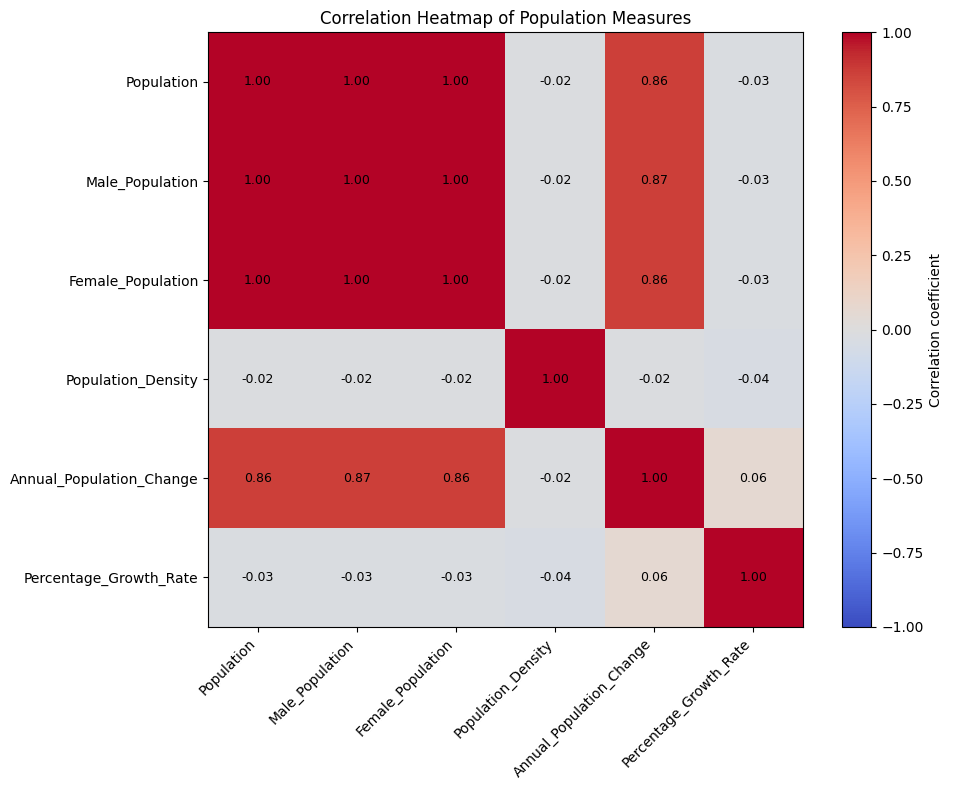

Interpretation: Total, male, and female population are strongly correlated, while population density and growth rate represent different dimensions of population change.


In [21]:
# Visualization 5: Correlation heatmap
correlation_columns = [
    "Population",
    "Male_Population",
    "Female_Population",
    "Population_Density",
    "Annual_Population_Change",
    "Percentage_Growth_Rate",
]

correlation_matrix = (
    cleaned_df[correlation_columns]
    .dropna()
    .corr()
)

plt.figure(figsize=(10, 8))
image = plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

plt.colorbar(image, label="Correlation coefficient")
plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(correlation_columns)),
    correlation_columns,
)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

plt.title("Correlation Heatmap of Population Measures")

save_current_figure("06_population_correlation_heatmap.png")
plt.show()

print(
    "Interpretation: Total, male, and female population are strongly "
    "correlated, while population density and growth rate represent "
    "different dimensions of population change."
)


Saved: /kaggle/working/population_analysis_outputs/figures/07_population_trends_by_continent.png


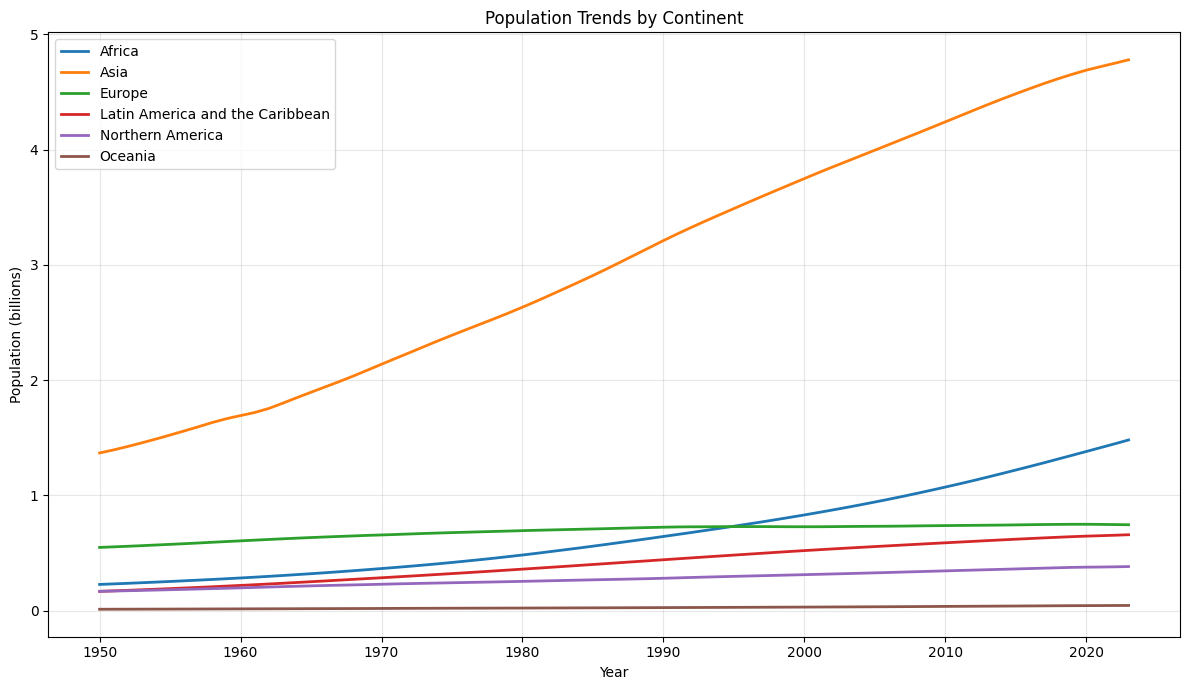

Interpretation: The chart highlights major differences in population scale and long-term growth across continents.


In [22]:
# Visualization 6: Population growth by continent
continent_population_trends = (
    cleaned_df.groupby(
        ["Continent", "Year"],
        as_index=False,
    )["Population"]
    .sum()
)

plt.figure(figsize=(12, 7))

for continent in sorted(
    continent_population_trends["Continent"].unique()
):
    continent_data = continent_population_trends[
        continent_population_trends["Continent"]
        == continent
    ]
    plt.plot(
        continent_data["Year"],
        billions(continent_data["Population"]),
        linewidth=2,
        label=continent,
    )

plt.title("Population Trends by Continent")
plt.xlabel("Year")
plt.ylabel("Population (billions)")
plt.legend()
plt.grid(alpha=0.3)

save_current_figure("07_population_trends_by_continent.png")
plt.show()

print(
    "Interpretation: The chart highlights major differences in "
    "population scale and long-term growth across continents."
)


## Part 6: Prediction and Forecasting

A separate Linear Regression model is developed for each selected country.

### Modelling approach

- Model input: Year  
- Model target: Population  
- Modelling period: 2005–2023  
- Training period: 2005–2018  
- Test period: 2019–2023  
- Forecast period: 2024–2033  
- Evaluation metrics: MAE, RMSE, and R²  

Linear Regression estimates a straight-line relationship between year and population. It provides an interpretable baseline forecast, but it does not directly account for fertility, mortality, migration, policy changes, conflict, or non-linear demographic transitions.


In [23]:
# Configure the forecasting analysis
forecast_countries = [
    "India",
    "China",
    "United States of America",
    "Germany",
    "Russian Federation",
]

MODEL_START_YEAR = 2005
TRAIN_END_YEAR = 2018
TEST_START_YEAR = 2019

future_years = np.arange(
    FORECAST_START_YEAR,
    FORECAST_END_YEAR + 1,
)

model_metrics = []
forecast_records = []
historical_and_forecast_records = []

for country in forecast_countries:
    country_data = cleaned_df[
        (cleaned_df["Country"] == country)
        & (cleaned_df["Year"] >= MODEL_START_YEAR)
    ][["Year", "Population"]].sort_values("Year")

    train_data = country_data[
        country_data["Year"] <= TRAIN_END_YEAR
    ]
    test_data = country_data[
        country_data["Year"] >= TEST_START_YEAR
    ]

    validation_model = LinearRegression()
    validation_model.fit(
        train_data[["Year"]],
        train_data["Population"],
    )

    test_predictions = validation_model.predict(
        test_data[["Year"]]
    )

    mae = mean_absolute_error(
        test_data["Population"],
        test_predictions,
    )
    rmse = np.sqrt(
        mean_squared_error(
            test_data["Population"],
            test_predictions,
        )
    )
    r_squared = r2_score(
        test_data["Population"],
        test_predictions,
    )

    model_metrics.append(
        {
            "Country": country,
            "Training_Start_Year": MODEL_START_YEAR,
            "Training_End_Year": TRAIN_END_YEAR,
            "Test_Start_Year": TEST_START_YEAR,
            "Test_End_Year": HISTORICAL_END_YEAR,
            "MAE": mae,
            "RMSE": rmse,
            "R_Squared": r_squared,
        }
    )

    final_model = LinearRegression()
    final_model.fit(
        country_data[["Year"]],
        country_data["Population"],
    )

    future_year_frame = pd.DataFrame(
        {"Year": future_years}
    )
    future_predictions = final_model.predict(
        future_year_frame
    )
    future_predictions = np.maximum(
        future_predictions,
        0,
    )

    for year, prediction in zip(
        future_years,
        future_predictions,
    ):
        forecast_records.append(
            {
                "Country": country,
                "Year": int(year),
                "Forecast_Population": int(round(prediction)),
            }
        )

    for _, row in country_data.iterrows():
        historical_and_forecast_records.append(
            {
                "Country": country,
                "Year": int(row["Year"]),
                "Population": int(row["Population"]),
                "Series": "Historical",
            }
        )

    for year, prediction in zip(
        future_years,
        future_predictions,
    ):
        historical_and_forecast_records.append(
            {
                "Country": country,
                "Year": int(year),
                "Population": int(round(prediction)),
                "Series": "Forecast",
            }
        )

model_metrics_df = pd.DataFrame(model_metrics)
forecast_df = pd.DataFrame(forecast_records)
forecast_plot_df = pd.DataFrame(
    historical_and_forecast_records
)

model_metrics_df.to_csv(
    TABLE_DIR / "linear_regression_model_metrics.csv",
    index=False,
)
forecast_df.to_csv(
    TABLE_DIR / "population_forecast_2024_2033.csv",
    index=False,
)

display(model_metrics_df)
display(forecast_df.head(15))


,Country,Training_Start_Year,Training_End_Year,Test_Start_Year,Test_End_Year,MAE,RMSE,R_Squared
0,India,2005,2018,2019,2023,"15,609,642.813","17,104,013.662",0.000
1,China,2005,2018,2019,2023,"21,943,783.134","25,323,894.991",-288.691
2,United States of America,2005,2018,2019,2023,"3,845,834.976","4,531,948.474",-4.544
3,Germany,2005,2018,2019,2023,"1,073,428.796","1,095,628.533",-7.753
4,Russian Federation,2005,2018,2019,2023,"707,580.568","820,514.278",-2.631


,Country,Year,Forecast_Population
0,India,2024,1465971810
1,India,2025,1481943704
2,India,2026,1497915597
3,India,2027,1513887491
4,India,2028,1529859384
5,India,2029,1545831277
6,India,2030,1561803171
7,India,2031,1577775064
8,India,2032,1593746958
9,India,2033,1609718851


Saved: /kaggle/working/population_analysis_outputs/figures/09_linear_regression_population_forecast.png


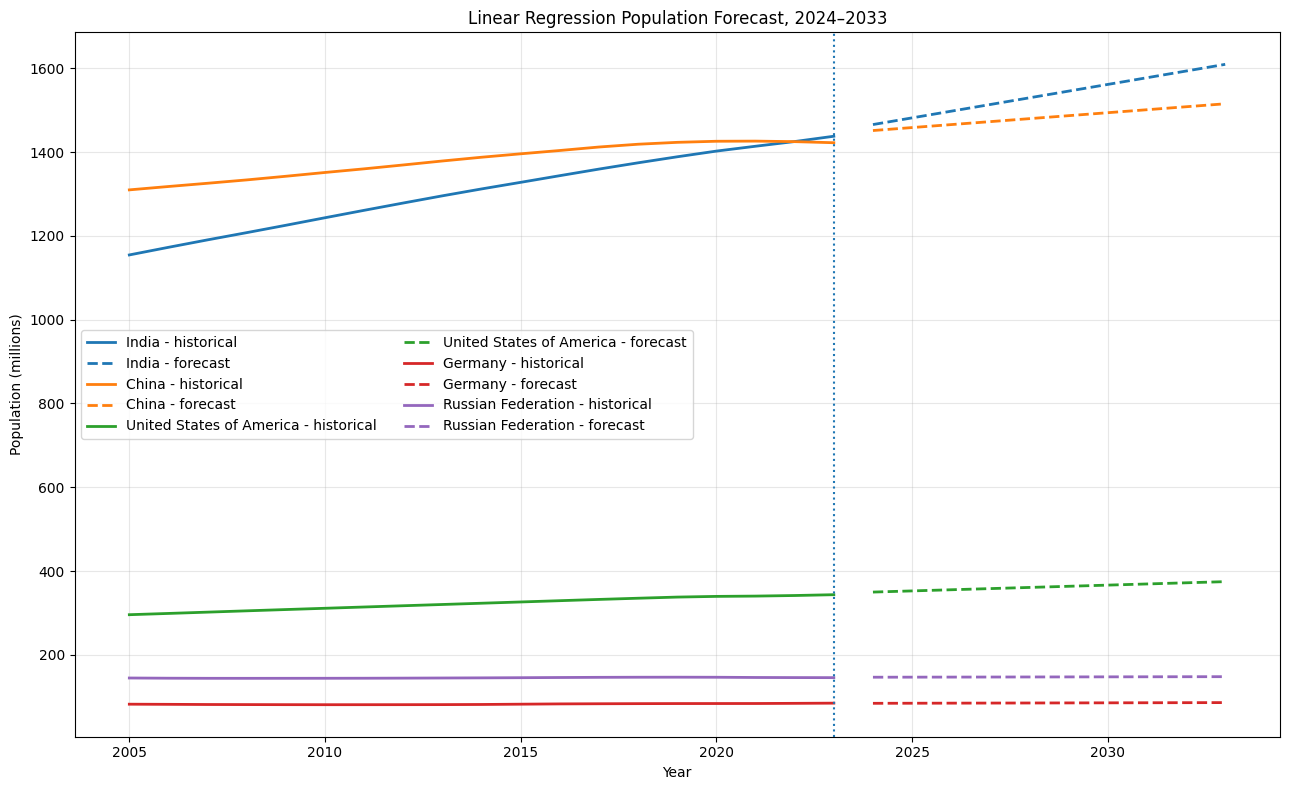

Interpretation: Dashed lines show the ten-year linear forecast. The forecast extends each country's recent historical trend and should be interpreted as a baseline estimate.


In [24]:
# Forecast visualization
plt.figure(figsize=(13, 8))

for country in forecast_countries:
    historical = forecast_plot_df[
        (forecast_plot_df["Country"] == country)
        & (forecast_plot_df["Series"] == "Historical")
    ]
    forecast = forecast_plot_df[
        (forecast_plot_df["Country"] == country)
        & (forecast_plot_df["Series"] == "Forecast")
    ]

    historical_line = plt.plot(
        historical["Year"],
        millions(historical["Population"]),
        linewidth=2,
        label=f"{country} - historical",
    )[0]

    plt.plot(
        forecast["Year"],
        millions(forecast["Population"]),
        linestyle="--",
        linewidth=2,
        color=historical_line.get_color(),
        label=f"{country} - forecast",
    )

plt.axvline(
    HISTORICAL_END_YEAR,
    linestyle=":",
    linewidth=1.5,
)
plt.title(
    "Linear Regression Population Forecast, 2024–2033"
)
plt.xlabel("Year")
plt.ylabel("Population (millions)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)

save_current_figure("09_linear_regression_population_forecast.png")
plt.show()

print(
    "Interpretation: Dashed lines show the ten-year linear "
    "forecast. The forecast extends each country's recent historical "
    "trend and should be interpreted as a baseline estimate."
)


In [25]:
# Forecast comparison between 2023 and 2033
actual_2023 = cleaned_df[
    (cleaned_df["Year"] == HISTORICAL_END_YEAR)
    & (cleaned_df["Country"].isin(forecast_countries))
][["Country", "Population"]].rename(
    columns={"Population": "Population_2023"}
)

forecast_2033 = forecast_df[
    forecast_df["Year"] == FORECAST_END_YEAR
][["Country", "Forecast_Population"]].rename(
    columns={"Forecast_Population": "Forecast_Population_2033"}
)

forecast_comparison = actual_2023.merge(
    forecast_2033,
    on="Country",
    how="inner",
)

forecast_comparison["Forecast_Absolute_Change"] = (
    forecast_comparison["Forecast_Population_2033"]
    - forecast_comparison["Population_2023"]
)

forecast_comparison["Forecast_Percentage_Change"] = (
    forecast_comparison["Forecast_Absolute_Change"]
    / forecast_comparison["Population_2023"]
    * 100
)

forecast_comparison.to_csv(
    TABLE_DIR / "forecast_2023_2033_comparison.csv",
    index=False,
)

display(forecast_comparison)


,Country,Population_2023,Forecast_Population_2033,Forecast_Absolute_Change,Forecast_Percentage_Change
0,China,1422584933,1515578136,92993203,6.537
1,Germany,84548231,85867521,1319290,1.560
2,India,1438069596,1609718851,171649255,11.936
3,Russian Federation,145440500,147759936,2319436,1.595
4,United States of America,343477335,374644075,31166740,9.074


In [26]:
# Create a final summary of generated outputs
generated_files = sorted(
    [
        str(path.relative_to(OUTPUT_DIR))
        for path in OUTPUT_DIR.rglob("*")
        if path.is_file()
    ]
)

output_manifest = pd.DataFrame(
    {"Generated_File": generated_files}
)
output_manifest.to_csv(
    OUTPUT_DIR / "output_manifest.csv",
    index=False,
)

display(output_manifest)

# Package all outputs for download
zip_path = Path(
    "/kaggle/working/population_analysis_outputs.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            archive.write(
                file_path,
                arcname=file_path.relative_to(
                    OUTPUT_DIR.parent
                ),
            )

print("Cleaned dataset:", CLEANED_DATA_PATH)
print("Complete output package:", zip_path)


,Generated_File
0,figures/01_total_population_over_time.png
1,figures/02_selected_country_population_trends.png
2,figures/03_top_10_most_populated_countries.png
3,figures/04_population_distribution_by_continen...
4,figures/05_population_size_vs_growth_rate.png
5,figures/06_population_correlation_heatmap.png
6,figures/07_population_trends_by_continent.png
7,figures/08_absolute_vs_percentage_growth.png
8,figures/09_linear_regression_population_foreca...
9,output_manifest.csv


Cleaned dataset: /kaggle/working/population_analysis_outputs/population_cleaned_1950_2023.csv
Complete output package: /kaggle/working/population_analysis_outputs.zip
